In [1]:
import pandas as pd
import sys
import pickle
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC
from IPython.display import display, HTML
import shap
import seaborn as sns
import matplotlib.pyplot as plt

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
sys.path.append('../utils_functionality/')
# from data_analysis.split_analisys import *
from data_analysis.reports import *
from models.class_models import *
from models.class_models import *
from models.hyperparams_tuning import *
from models.blending import *

Imported 0.3.2 version. Select nrows to a small number when running on huge datasets.
output = featurewiz(dataname, target, corr_limit=0.90, verbose=2, sep=',', 
		header=0, test_data='',feature_engg='', category_encoders='',
		dask_xgboost_flag=False, nrows=None, skip_sulov=False, skip_xgboost=False)
Create new features via 'feature_engg' flag : ['interactions','groupby','target']



In [3]:
RANDOM_STATE = 42

# Загрузка данных и разделение на train, test

In [4]:
df = pd.read_excel('../data/df_merged_edited.xlsx', index_col=[0])
df.reset_index(inplace=True, drop=True)
train, test = train_test_split(df, test_size=0.33, random_state=RANDOM_STATE)

# Интерпретация лучшей модели для splashing

In [5]:
features = ['Re', 'We', 'wettability', 'roughness', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio', 
            'surface_tension', 'viscosity']

In [6]:
cs = CreateSamples(df, train, test, target='splashing', features=features, get_pf=True)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness,Re,We,Re_1/4,We_1/4,Re_1/4^2,Re_1/4 We_1/4,We_1/4^2
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0.04,2110.385675,833.534028,6.777827,5.373173,45.938934,36.418436,28.870989
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,10.89,2022.562172,798.846587,6.706184,5.316378,44.972905,35.652609,28.263874
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,2.49,661.664919,891.662791,5.071770,5.464497,25.722848,27.714668,29.860723
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0.10,649.524278,875.302006,5.048343,5.439256,25.485766,27.459228,29.585503
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0.04,1466.205641,1465.995744,6.187977,6.187756,38.291065,38.289694,38.288324


In [7]:
cat_features = [0, 5]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [8]:
model = CatBoostClassifier()
model = model.load_model('../utils_functionality/models/models_pickles/tuned_models/splashing_pf_1')

In [9]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

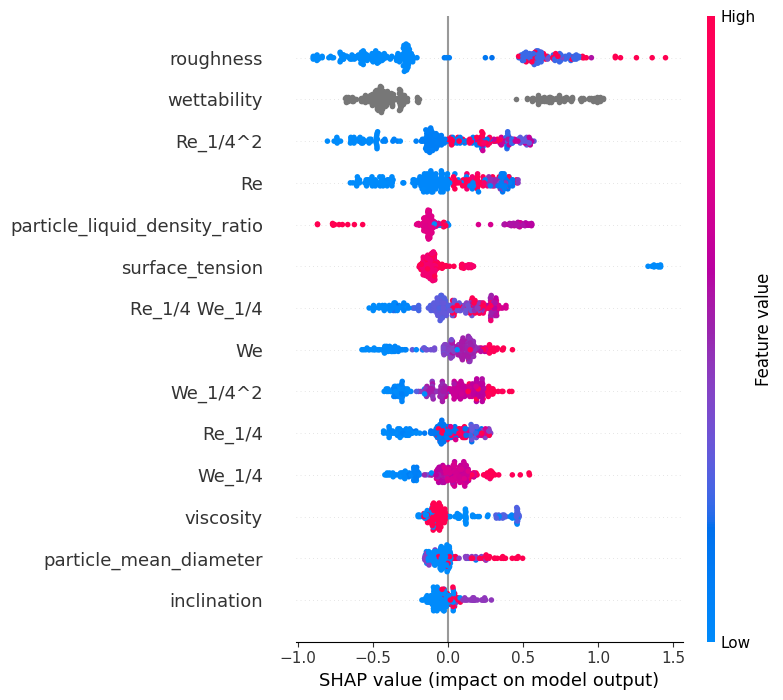

<Figure size 640x480 with 0 Axes>

In [10]:
shap.summary_plot(shap_values, X_train)
plt.savefig('../plots/splashing_pf_1_shap.pdf', format='pdf')

In [11]:
importances = model.get_feature_importance()
df_plot = pd.DataFrame(
    {key: [importances[i]] for i, key in enumerate(X_train.columns) }
).T
df_plot.sort_values(by=0, inplace=True, ascending=False)
df_plot.rename(columns={0: 'Feature Importance'}, inplace=True)

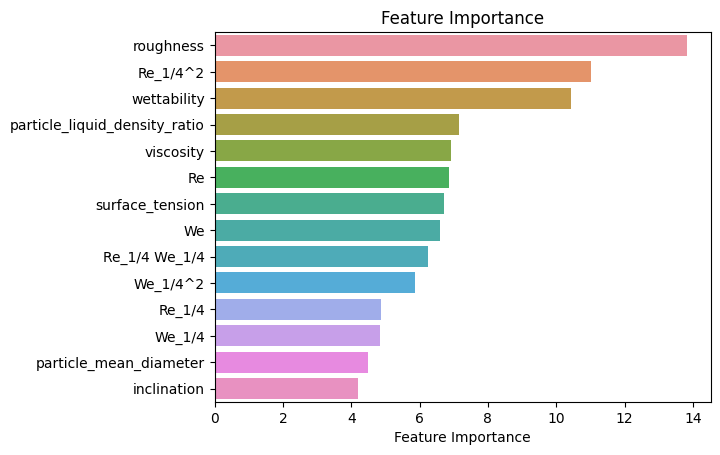

In [12]:
sns.barplot(
    x=df_plot['Feature Importance'],
    y=df_plot.index,
    orient='h'
)
plt.title('Feature Importance')
plt.savefig('../plots/splashing_pf_1_fi.pdf', format='pdf')
plt.show()

# Интерепретация лучшей модели для net_impact

In [13]:
features = ['Re', 'We', 'wettability', 'roughness_binary', 'inclination', 
            'particle_mean_diameter', 'particle_liquid_density_ratio',
            'volume_fraction_binary', 'surface_tension', 'viscosity']

In [14]:
cs = CreateSamples(df, train, test, target='net_impact', features=features)
X_train, X_test, y_train, y_test = cs.get_samples()
X_train.head()

,inclination,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,wettability,roughness_binary,volume_fraction_binary,Re,We
31,0,0.0691,0.00689,0.000041,0.877193,neutral,0,1,2110.385675,833.534028
36,0,0.0691,0.00689,0.000041,0.877193,lyophilic,1,1,2022.562172,798.846587
158,0,0.0679,0.02310,0.000041,1.864407,lyophobic,0,0,661.664919,891.662791
183,0,0.0679,0.02310,0.000041,0.847458,lyophilic,0,1,649.524278,875.302006
168,0,0.0269,0.00679,0.000041,1.219512,neutral,0,0,1466.205641,1465.995744


In [15]:
cat_features = [0, 5]
smote_nc = SMOTENC(categorical_features=cat_features, random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [16]:
model = CatBoostClassifier()
model = model.load_model('../utils_functionality/models/models_pickles/tuned_models/net_impact_alternative_1')

In [17]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

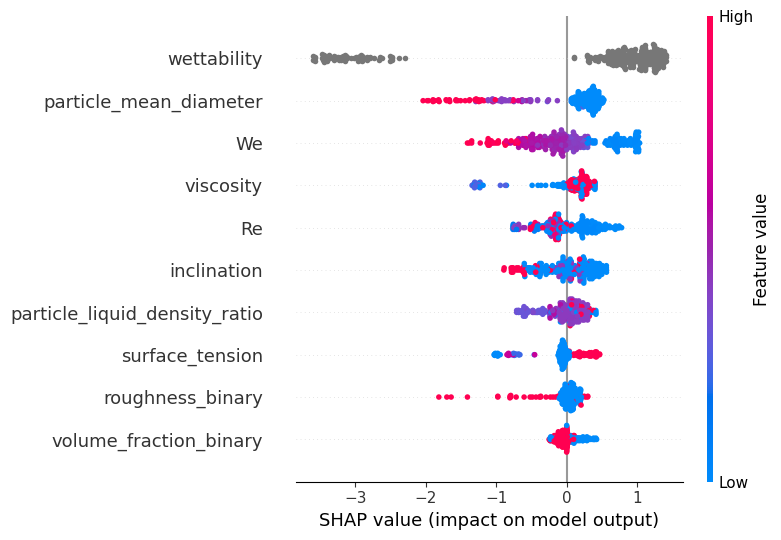

<Figure size 640x480 with 0 Axes>

In [18]:
shap.summary_plot(shap_values, X_train)
plt.savefig('../plots/net_impact_alternative_shap.pdf', format='pdf')

In [19]:
importances = model.get_feature_importance()
df_plot = pd.DataFrame(
    {key: [importances[i]] for i, key in enumerate(X_train.columns) }
).T
df_plot.sort_values(by=0, inplace=True, ascending=False)
df_plot.rename(columns={0: 'Feature Importance'}, inplace=True)

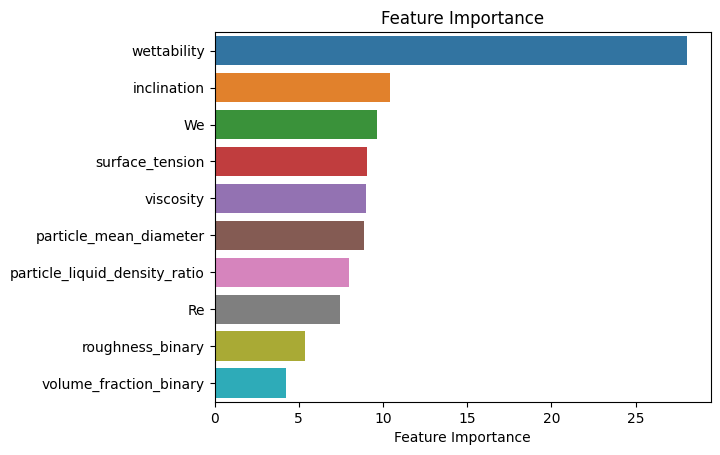

In [20]:
sns.barplot(
    x=df_plot['Feature Importance'],
    y=df_plot.index,
    orient='h'
)
plt.title('Feature Importance')
plt.savefig('../plots/net_impact_alternative_fi.pdf', format='pdf')
plt.show()